# AirIntel

# Notebook 01 – Data Extraction

## Objectives

This notebook performs the first stage of the AirIntel data engineering pipeline.

The objectives are:

- Load and inspect the AirQualityBench dataset.
- Explore station coordinate information.
- Identify Indian monitoring stations using geospatial analysis.
- Extract hourly pollutant observations for India.
- Convert the extracted observations into a tabular dataset.
- Save the processed dataset in CSV and Parquet formats.
- Generate an extraction summary report.

### Input

- AirQualityBench (2021–2025)
- Station coordinate dataset
- Natural Earth country boundaries

### Output

- india_air_quality.csv
- india_air_quality.parquet
- extraction_report.csv

## Import Libraries

In [71]:
import warnings
from pathlib import Path

import h5py
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

## Project Configuration

In [72]:
# Define project directories

PROJECT_ROOT = Path("..")

RAW_DATA = PROJECT_ROOT / "data" / "raw"
EXTERNAL_DATA = PROJECT_ROOT / "data" / "external"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"

# Create output folders

PROCESSED_DATA.mkdir(exist_ok=True)
REPORTS.mkdir(exist_ok=True)

# Project configuration

CONFIG = {
    "years": [2021, 2022, 2023, 2024, 2025],
    "country": "India",
    "pollutants": [
        "PM2.5",
        "PM10",
        "NO2",
        "SO2",
        "CO",
        "O3"
    ]
}

## Verify Input Files

In [73]:
required_files = [
    "aq_compact_2021.h5",
    "aq_compact_2022.h5",
    "aq_compact_2023.h5",
    "aq_compact_2024.h5",
    "aq_compact_2025.h5",
]

missing_files = []

print("Checking required files...\n")

for file in required_files:

    file_path = RAW_DATA / file

    if file_path.exists():
        print(f"✅ {file}")
    else:
        print(f"❌ {file}")
        missing_files.append(file)

if missing_files:
    print("\nMissing Files:")
    print(missing_files)
else:
    print("\nAll required files are available.")

Checking required files...

✅ aq_compact_2021.h5
✅ aq_compact_2022.h5
✅ aq_compact_2023.h5
✅ aq_compact_2024.h5
✅ aq_compact_2025.h5

All required files are available.


In [74]:
station_coordinates = pd.read_csv(
    RAW_DATA / "selected_nodes_metadata.csv"
)
station_coordinates.shape

(3720, 3)

In [75]:
station_coordinates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3720 entries, 0 to 3719
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   station_id  3720 non-null   int64  
 1   lat         3720 non-null   float64
 2   lon         3720 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 87.3 KB


In [76]:
station_coordinates.describe().T

,count,mean,std,min,25%,50%,75%,max
station_id,3720.000,35510.002,125085.638,25.000,1724.000,4044.500,8600.750,4337379.000
lat,3720.000,38.139,19.423,-45.580,36.054,42.057,48.643,78.907
lon,3720.000,-37.963,65.390,-158.089,-93.650,-19.881,10.664,153.158


## Load Country Boundary

In [77]:
countries = gpd.read_file(
    EXTERNAL_DATA /
    "natural_earth" /
    "ne_10m_admin_0_countries.shp"
)

print(f"Shape : {countries.shape}")

Shape : (258, 169)


In [78]:
countries.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,ADM0_A3,GEOU_DIF,GEOUNIT,GU_A3,SU_DIF,SUBUNIT,SU_A3,BRK_DIFF,NAME,NAME_LONG,BRK_A3,BRK_NAME,BRK_GROUP,ABBREV,POSTAL,FORMAL_EN,FORMAL_FR,NAME_CIAWF,NOTE_ADM0,NOTE_BRK,NAME_SORT,NAME_ALT,MAPCOLOR7,MAPCOLOR8,MAPCOLOR9,MAPCOLOR13,POP_EST,POP_RANK,POP_YEAR,GDP_MD,GDP_YEAR,ECONOMY,INCOME_GRP,FIPS_10,ISO_A2,ISO_A2_EH,ISO_A3,ISO_A3_EH,ISO_N3,ISO_N3_EH,UN_A3,WB_A2,WB_A3,WOE_ID,WOE_ID_EH,WOE_NOTE,ADM0_ISO,ADM0_DIFF,ADM0_TLC,ADM0_A3_US,ADM0_A3_FR,ADM0_A3_RU,ADM0_A3_ES,ADM0_A3_CN,ADM0_A3_TW,ADM0_A3_IN,ADM0_A3_NP,ADM0_A3_PK,ADM0_A3_DE,ADM0_A3_GB,ADM0_A3_BR,ADM0_A3_IL,ADM0_A3_PS,ADM0_A3_SA,ADM0_A3_EG,ADM0_A3_MA,ADM0_A3_PT,ADM0_A3_AR,ADM0_A3_JP,ADM0_A3_KO,ADM0_A3_VN,ADM0_A3_TR,ADM0_A3_ID,ADM0_A3_PL,ADM0_A3_GR,ADM0_A3_IT,ADM0_A3_NL,ADM0_A3_SE,ADM0_A3_BD,ADM0_A3_UA,ADM0_A3_UN,ADM0_A3_WB,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,MIN_ZOOM,MIN_LABEL,MAX_LABEL,LABEL_X,LABEL_Y,NE_ID,WIKIDATAID,NAME_AR,NAME_BN,NAME_DE,NAME_EN,NAME_ES,NAME_FA,NAME_FR,NAME_EL,NAME_HE,NAME_HI,NAME_HU,NAME_ID,NAME_IT,NAME_JA,NAME_KO,NAME_NL,NAME_PL,NAME_PT,NAME_RU,NAME_SV,NAME_TR,NAME_UK,NAME_UR,NAME_VI,NAME_ZH,NAME_ZHT,FCLASS_ISO,TLC_DIFF,FCLASS_TLC,FCLASS_US,FCLASS_FR,FCLASS_RU,FCLASS_ES,FCLASS_CN,FCLASS_TW,FCLASS_IN,FCLASS_NP,FCLASS_PK,FCLASS_DE,FCLASS_GB,FCLASS_BR,FCLASS_IL,FCLASS_PS,FCLASS_SA,FCLASS_EG,FCLASS_MA,FCLASS_PT,FCLASS_AR,FCLASS_JP,FCLASS_KO,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,IDN,0,Indonesia,IDN,0,Indonesia,IDN,0,Indonesia,Indonesia,IDN,Indonesia,None,Indo.,INDO,Republic of Indonesia,None,Indonesia,None,None,Indonesia,None,6,6,6,11,270625568.000,17,2019,1119190,2019,4. Emerging region: MIKT,4. Lower middle income,ID,ID,ID,IDN,IDN,360,360,360,ID,IDN,23424846,23424846,Exact WOE match as country,IDN,None,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,-99,-99,Asia,Asia,South-Eastern Asia,East Asia & Pacific,9,9,5,-99,1,0.000,1.700,6.700,101.893,-0.954,1159320845,Q252,إندونيسيا,ইন্দোনেশিয়া,Indonesien,Indonesia,Indonesia,اندونزی,Indonésie,Ινδονησία,אינדונזיה,इंडोनेशिया,Indonézia,Indonesia,Indonesia,インドネシア,인도네시아,Indonesië,Indonezja,Indonésia,Индонезия,Indonesien,Endonezya,Індонезія,انڈونیشیا,Indonesia,印度尼西亚,印度尼西亞,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,MYS,0,Malaysia,MYS,0,Malaysia,MYS,0,Malaysia,Malaysia,MYS,Malaysia,None,Malay.,MY,Malaysia,None,Malaysia,None,None,Malaysia,None,2,4,3,6,31949777.000,15,2019,364681,2019,6. Developing region,3. Upper middle income,MY,MY,MY,MYS,MYS,458,458,458,MY,MYS,23424901,23424901,Exact WOE match as country,MYS,None,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,-99,-99,Asia,Asia,South-Eastern Asia,East Asia & Pacific,8,8,6,-99,1,0.000,3.000,8.000,113.837,2.529,1159321083,Q833,ماليزيا,মালয়েশিয়া,Malaysia,Malaysia,Malasia,مالزی,Malaisie,Μαλαισία,מלזיה,मलेशिया,Malajzia,Malaysia,Malaysia,マレーシア,말레이시아,Maleisië,Malezja,Malásia,Малайзия,Malaysia,Malezya,Малайзія,ملائیشیا,Malaysia,马来西亚,馬來西亞,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,CHL,0,Chile,CHL,0,Chile,CHL,0,Chile,Chile,CHL,Chile,None,Chile,CL,Republic of Chile,None,Chile,None,None,Chile,None,5,1,5,9,18952038.000,14,2019,282318,2019,5. 

In [79]:
countries.columns.tolist()

['featurecla',
 'scalerank',
 'LABELRANK',
 'SOVEREIGNT',
 'SOV_A3',
 'ADM0_DIF',
 'LEVEL',
 'TYPE',
 'TLC',
 'ADMIN',
 'ADM0_A3',
 'GEOU_DIF',
 'GEOUNIT',
 'GU_A3',
 'SU_DIF',
 'SUBUNIT',
 'SU_A3',
 'BRK_DIFF',
 'NAME',
 'NAME_LONG',
 'BRK_A3',
 'BRK_NAME',
 'BRK_GROUP',
 'ABBREV',
 'POSTAL',
 'FORMAL_EN',
 'FORMAL_FR',
 'NAME_CIAWF',
 'NOTE_ADM0',
 'NOTE_BRK',
 'NAME_SORT',
 'NAME_ALT',
 'MAPCOLOR7',
 'MAPCOLOR8',
 'MAPCOLOR9',
 'MAPCOLOR13',
 'POP_EST',
 'POP_RANK',
 'POP_YEAR',
 'GDP_MD',
 'GDP_YEAR',
 'ECONOMY',
 'INCOME_GRP',
 'FIPS_10',
 'ISO_A2',
 'ISO_A2_EH',
 'ISO_A3',
 'ISO_A3_EH',
 'ISO_N3',
 'ISO_N3_EH',
 'UN_A3',
 'WB_A2',
 'WB_A3',
 'WOE_ID',
 'WOE_ID_EH',
 'WOE_NOTE',
 'ADM0_ISO',
 'ADM0_DIFF',
 'ADM0_TLC',
 'ADM0_A3_US',
 'ADM0_A3_FR',
 'ADM0_A3_RU',
 'ADM0_A3_ES',
 'ADM0_A3_CN',
 'ADM0_A3_TW',
 'ADM0_A3_IN',
 'ADM0_A3_NP',
 'ADM0_A3_PK',
 'ADM0_A3_DE',
 'ADM0_A3_GB',
 'ADM0_A3_BR',
 'ADM0_A3_IL',
 'ADM0_A3_PS',
 'ADM0_A3_SA',
 'ADM0_A3_EG',
 'ADM0_A3_MA',
 'ADM0_A3_PT

In [80]:
## Identify the India Boundary
india_boundary = countries[
    countries["NAME"] == "India"
].copy()

print(india_boundary.shape)

india_boundary[[
    "NAME",
    "CONTINENT",
    "SUBREGION",
    "POP_EST"
]]

(1, 169)


,NAME,CONTINENT,SUBREGION,POP_EST
8,India,Asia,Southern Asia,1366417754.000


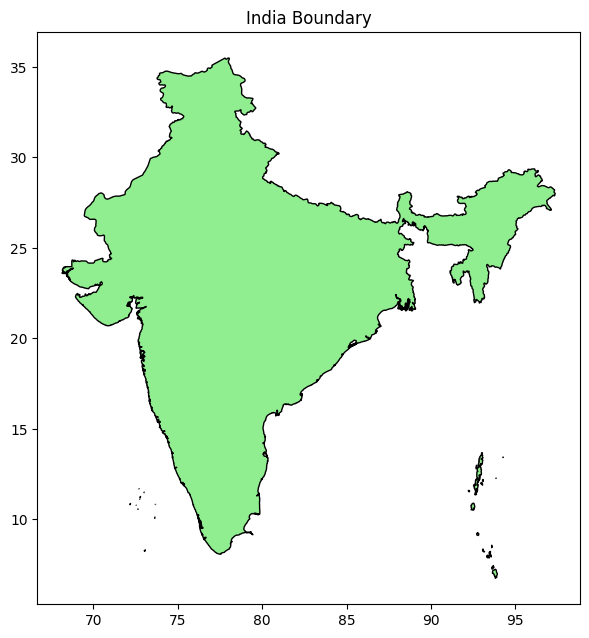

In [81]:
fig, ax = plt.subplots(figsize=(7, 8))

india_boundary.plot(
    ax=ax,
    color="lightgreen",
    edgecolor="black"
)

ax.set_title("India Boundary")

plt.show()

In [82]:
# Convert station coordinates into a GeoDataFrame

station_gdf = gpd.GeoDataFrame(
    station_coordinates,
    geometry=gpd.points_from_xy(
        station_coordinates["lon"],
        station_coordinates["lat"]
    ),
    crs="EPSG:4326"
)

print(f"Total monitoring stations : {len(station_gdf):,}")

Total monitoring stations : 3,720


In [83]:
# Verify that both datasets use the same coordinate reference system

print(f"Station CRS : {station_gdf.crs}")
print(f"India CRS   : {india_boundary.crs}")

Station CRS : EPSG:4326
India CRS   : EPSG:4326


In [84]:
# Reproject station coordinates if required

if station_gdf.crs != india_boundary.crs:
    station_gdf = station_gdf.to_crs(india_boundary.crs)

In [85]:
# Perform a spatial join to identify stations inside India's boundary

indian_stations = gpd.sjoin(
    station_gdf,
    india_boundary,
    how="inner",
    predicate="within"
)

print(f"Indian monitoring stations : {len(indian_stations):,}")

Indian monitoring stations : 4


In [86]:
# Preview the extracted Indian stations

indian_stations[
    ["station_id", "lat", "lon"]
].head()

,station_id,lat,lon
3054,8039,19.073,72.883
3079,8118,28.636,77.224
3243,8557,17.384,78.456
3244,8558,13.088,80.278


In [87]:
# Check for duplicate station IDs

duplicate_stations = indian_stations["station_id"].duplicated().sum()

print(f"Duplicate station IDs : {duplicate_stations}")

Duplicate station IDs : 0


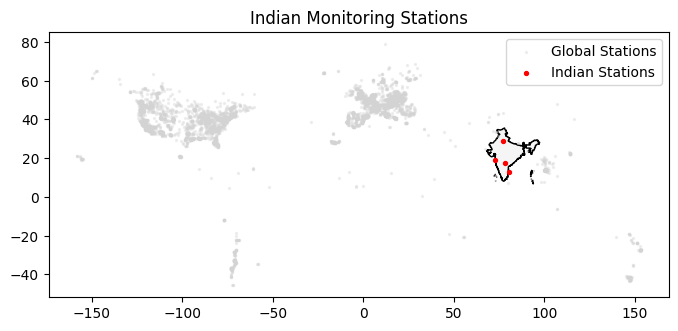

In [88]:
# Visualize Indian monitoring stations

fig, ax = plt.subplots(figsize=(8, 9))

india_boundary.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="black"
)

station_gdf.plot(
    ax=ax,
    color="lightgray",
    markersize=2,
    alpha=0.3,
    label="Global Stations"
)

indian_stations.plot(
    ax=ax,
    color="red",
    markersize=8,
    label="Indian Stations"
)

ax.set_title("Indian Monitoring Stations")

ax.legend()

plt.show()

## Explore the AirQualityBench HDF5 Structure


In [89]:
# Load one HDF5 file for schema inspection

sample_file = RAW_DATA / "aq_compact_2025.h5"

with h5py.File(sample_file, "r") as h5_file:

    print("Available datasets:\n")

    for key in h5_file.keys():
        print(f"• {key}")

Available datasets:

• masks
• params
• station_ids
• values


In [90]:
# Display the shape and datatype of each dataset

with h5py.File(sample_file, "r") as h5_file:

    hdf5_summary = []

    for key in h5_file.keys():

        hdf5_summary.append({

            "Dataset": key,

            "Shape": h5_file[key].shape,

            "Data Type": str(h5_file[key].dtype)

        })

hdf5_summary = pd.DataFrame(hdf5_summary)

hdf5_summary

,Dataset,Shape,Data Type
0,masks,"(8760, 3720, 6)",bool
1,params,"(6,)",|S4
2,station_ids,"(3720,)",|S7
3,values,"(8760, 3720, 6)",float32


In [91]:
# Read pollutant names

with h5py.File(sample_file, "r") as h5_file:

    pollutants = [
        pollutant.decode()
        for pollutant in h5_file["params"][:]
    ]

pollutants

['pm25', 'pm10', 'no2', 'o3', 'so2', 'co']

In [92]:
# Read station IDs from the HDF5 file

with h5py.File(sample_file, "r") as h5_file:

    hdf5_station_ids = [
        int(station.decode())
        for station in h5_file["station_ids"][:]
    ]

print(f"Total station IDs : {len(hdf5_station_ids):,}")

Total station IDs : 3,720


In [93]:
# Match Indian station IDs with HDF5 station IDs

matched_station_ids = sorted(
    set(indian_stations["station_id"])
    &
    set(hdf5_station_ids)
)

print(f"Matched Indian stations : {len(matched_station_ids):,}")

Matched Indian stations : 4


In [94]:
len(indian_stations)

4

In [95]:
indian_stations[
    ["station_id", "lat", "lon"]
]

,station_id,lat,lon
3054,8039,19.073,72.883
3079,8118,28.636,77.224
3243,8557,17.384,78.456
3244,8558,13.088,80.278


In [96]:
india_boundary.total_bounds

array([68.14340254,  6.74555085, 97.36225305, 35.49540558])

In [97]:
station_coordinates[["lat", "lon"]].describe()

,lat,lon
count,3720.000,3720.000
mean,38.139,-37.963
std,19.423,65.390
min,-45.580,-158.089
25%,36.054,-93.650
50%,42.057,-19.881
75%,48.643,10.664
max,78.907,153.158


In [98]:
metadata = pd.read_csv(
    RAW_DATA / "selected_nodes_metadata.csv"
)

metadata.columns.tolist()

['station_id', 'lat', 'lon']

In [99]:
metadata.head()

,station_id,lat,lon
0,100,52.334,4.774
1,1000,46.682,-68.016
2,1002,38.490,-90.705
3,1003,39.462,-76.632
4,1004,-38.765,-72.599


In [100]:
metadata = pd.read_csv(
    RAW_DATA / "selected_nodes_metadata.csv"
)

metadata.head()

,station_id,lat,lon
0,100,52.334,4.774
1,1000,46.682,-68.016
2,1002,38.490,-90.705
3,1003,39.462,-76.632
4,1004,-38.765,-72.599


In [101]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3720 entries, 0 to 3719
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   station_id  3720 non-null   int64  
 1   lat         3720 non-null   float64
 2   lon         3720 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 87.3 KB


In [102]:
metadata.columns

Index(['station_id', 'lat', 'lon'], dtype='object')

In [103]:
all_coords = pd.read_csv(
    RAW_DATA / "all_stations_coords.csv"
)

selected_nodes = pd.read_csv(
    RAW_DATA / "selected_nodes_metadata.csv"
)

print(all_coords.shape)
print(selected_nodes.shape)

(19496, 3)
(3720, 3)


In [104]:
all_coords.equals(selected_nodes)

False

In [105]:
# Compare station ID ranges

print("Metadata")
print(selected_nodes["station_id"].min())
print(selected_nodes["station_id"].max())

print("\nHDF5")

print(min(hdf5_station_ids))
print(max(hdf5_station_ids))

Metadata
25
4337379

HDF5
25
4337379


In [106]:
print(len(indian_stations))
print(len(matched_station_ids))

4
4


In [107]:
india_boundary[["ADMIN", "NAME", "NAME_LONG"]]

,ADMIN,NAME,NAME_LONG
8,India,India,India


In [108]:
india_boundary.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)

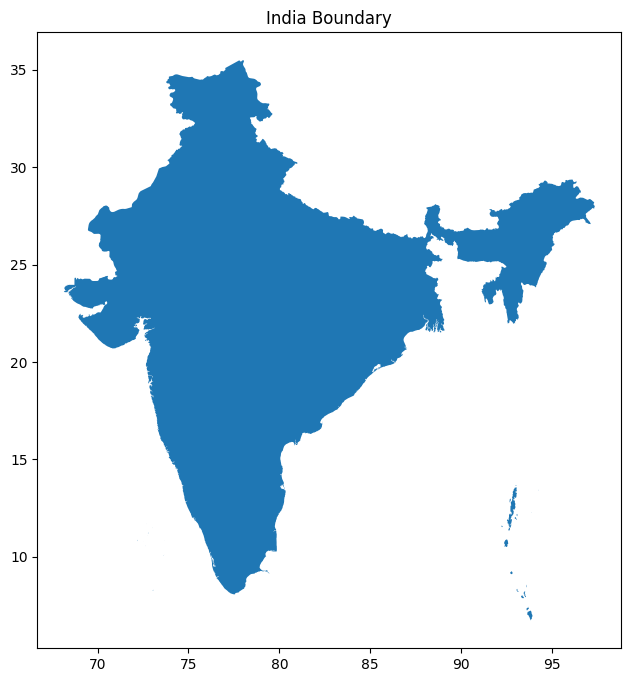

In [109]:
india_boundary.plot(figsize=(8, 8))
plt.title("India Boundary")
plt.show()

In [110]:
indian_stations[["station_id", "lat", "lon"]]

,station_id,lat,lon
3054,8039,19.073,72.883
3079,8118,28.636,77.224
3243,8557,17.384,78.456
3244,8558,13.088,80.278


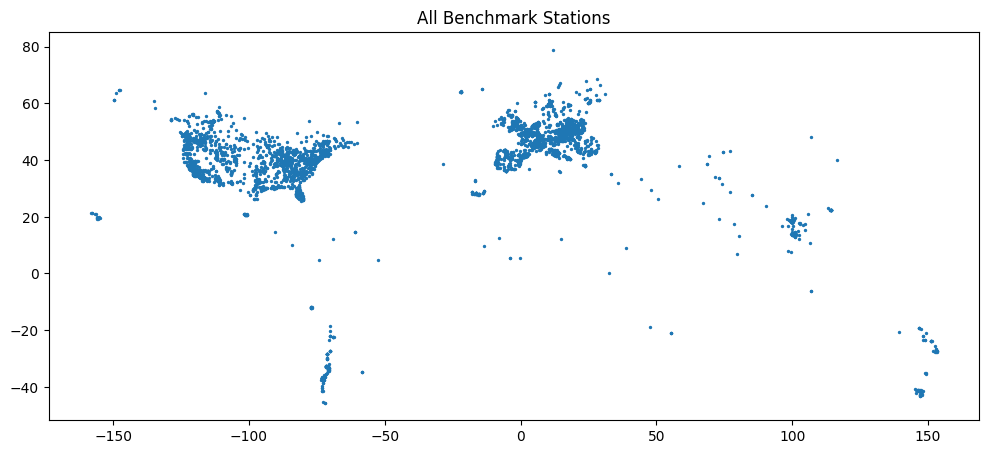

In [111]:
station_gdf.plot(figsize=(12, 6), markersize=2)
plt.title("All Benchmark Stations")
plt.show()

In [112]:
station_gdf.cx[68:98, 6:38]

,station_id,lat,lon,geometry
1092,225648,19.305,97.972,POINT (97.97165 19.30455)
1278,233470,33.726,73.116,POINT (73.11602 33.72561)
1759,3459,27.739,85.336,POINT (85.3362 27.7387)
1760,3460,27.712,85.316,POINT (85.3157 27.71246)
2753,7153,16.826,96.144,POINT (96.1445 16.8256)
3054,8039,19.073,72.883,POINT (72.88261 19.07283)
3060,8054,6.913,79.849,POINT (79.84868 6.91325)
3074,8088,34.006,71.538,POINT (71.53775 34.00585)
3079,8118,28.636,77.224,POINT (77.22445 28.63576)
3166,8415,23.796,90.425,POINT (90.42461 23.79637)


In [113]:
india_polygon = india_boundary.geometry.iloc[0]

indian_stations = station_gdf[
    station_gdf.geometry.intersects(india_polygon)
]

print(len(indian_stations))

4


In [114]:
indian_stations = station_gdf[
    station_gdf.geometry.within(india_polygon.buffer(0))
]

print(len(indian_stations))

4


In [115]:
india_boundary[["ADMIN", "NAME", "NAME_LONG"]]

,ADMIN,NAME,NAME_LONG
8,India,India,India


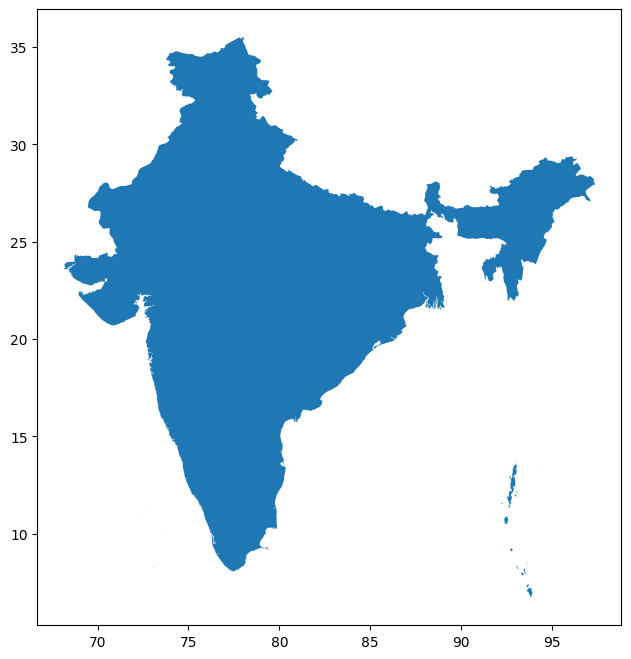

In [116]:
india_boundary.plot(figsize=(8,8))
plt.show()

In [117]:
# Show the stations that the polygon considers Indian

indian_stations[["station_id", "lat", "lon"]]

,station_id,lat,lon
3054,8039,19.073,72.883
3079,8118,28.636,77.224
3243,8557,17.384,78.456
3244,8558,13.088,80.278


In [118]:
# Find stations close to India's boundary

station_gdf[
    (station_gdf["lat"].between(6, 38)) &
    (station_gdf["lon"].between(68, 98))
][["station_id", "lat", "lon"]].sort_values(["lat", "lon"])

,station_id,lat,lon
3060,8054,6.913,79.849
3244,8558,13.088,80.278
2753,7153,16.826,96.144
3243,8557,17.384,78.456
3054,8039,19.073,72.883
1092,225648,19.305,97.972
3166,8415,23.796,90.425
1760,3460,27.712,85.316
1759,3459,27.739,85.336
3079,8118,28.636,77.224


In [119]:
india_boundary.crs
station_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [120]:
india_boundary.geometry.iloc[0].geom_type

'MultiPolygon'

In [121]:
india_boundary.geometry.iloc[0].is_valid

True

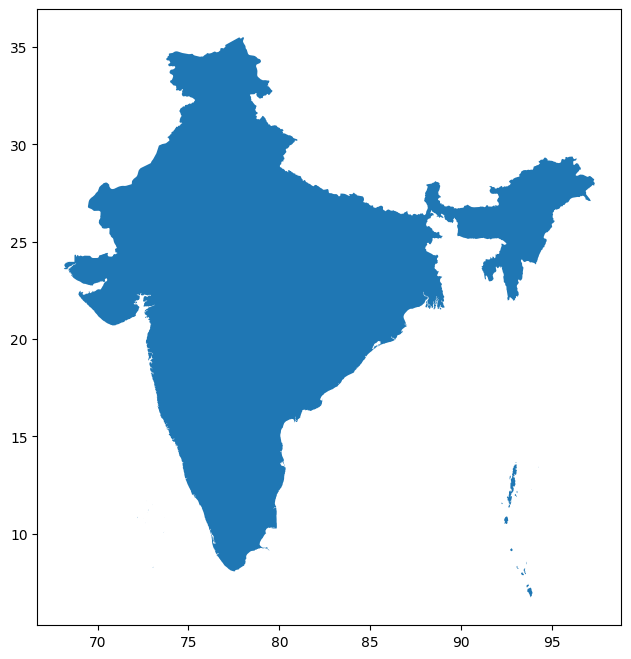

In [122]:
india_boundary.explode(index_parts=False).plot(figsize=(8,8))
plt.show()

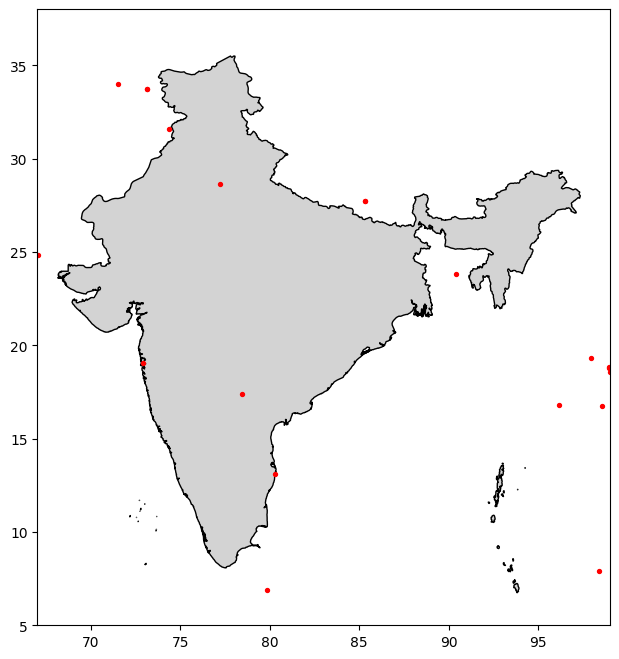

In [123]:
fig, ax = plt.subplots(figsize=(8,8))

india_boundary.plot(ax=ax, color="lightgray", edgecolor="black")

station_gdf.plot(
    ax=ax,
    color="red",
    markersize=8
)

plt.xlim(67,99)
plt.ylim(5,38)

plt.show()

In [124]:
india = station_gdf[station_gdf.within(india_polygon.unary_union)]

print(india.shape)
display(india)

AttributeError: 'MultiPolygon' object has no attribute 'unary_union'

In [125]:
india = station_gdf[station_gdf.within(india_polygon.unary_union)]

print(india.shape)
display(india)

AttributeError: 'MultiPolygon' object has no attribute 'unary_union'